# Switch Placement and Observed Order (No Contact)

Campaign A of `guideline/planning/evidence_plan.md` in the SysSimX-Framework-Paper
repository. This notebook is the single source; the paper repository holds only the
numbers it emits.
It closes the two gaps that block the paper's central claim:

- **RQ1 placement.** How far is a located runtime replacement from the true
  crossing, and does that distance depend on the macro step?
- **Convergence order.** The observed order of accuracy of the coupled run,
  fitted rather than asserted. The step sweep in notebook 4 already exists but
  its slope was never fitted, and it does not switch.

**Contact-free on purpose.** Repeated impacts amplify sub-millisecond timing
differences, so the contact case of notebooks 5 and 6 cannot answer the
placement question. This notebook reuses the plant and loop of notebook 7.

## Design

The macro step is swept while **the models' own discretization is held fixed**:
`FEM_INTERNAL_DT` is constant across every run and equal to the reference macro
step. Refining only the communication grid is what separates placement error
from model discretization error.

The reference is the same switched configuration at the finest macro step. Three
quantities come out of each run, and **they must not be conflated**:

| Quantity | Definition | What it can and cannot see |
|---|---|---|
| indicator residual | distance of the switching key from its armed threshold at the located instant | bisection quality against the trajectory the algorithm was given; blind to an error in that trajectory |
| placement error | located switch time at a step, against the located switch time of the reference | the quantity the paper needs; it inherits the trajectory error, so it is bounded by the coupling accuracy and not by the bisection tolerance |
| trajectory error | the plant angle against the reference, interpolated onto the run's own grid | the coupling accuracy itself |

The distinction is the point. Bisection can place a crossing to `tol_time` on
a trajectory that is itself wrong by far more than `tol_time` worth of motion.
The earlier ramp-model table in `paper_plan.md` section 5 could not show this,
because its crossing was analytic and its trajectory exact at every step.

### The grid-placed comparison is a counterfactual, not a run

`paper_plan.md` §5 describes a controlled experiment between grid-placed
switching via `mode_selector` and event-localized switching. **That API no
longer exists**: `c306370 feat!: remove legacy MultiComponent switching APIs`
removed it, so the recorded ramp-model table cannot be reproduced at the frozen
revision.

What is computed here instead is the grid-placed placement error a run *would*
have had, from the located crossing time and the macro step:

$$e_\mathrm{grid}(\Delta t) = \lceil t_\ast / \Delta t \rceil \, \Delta t - t_\ast$$

That is exact for the placement error and gives the expected O(Δt) sawtooth,
but it does **not** capture how a grid-placed switch would perturb the coupled
trajectory. Closing that needs a grid-placement policy back in the framework;
until then, do not claim a measured trajectory comparison between the two
strategies.

> **SMOKE defaults to `True`.** A smoke run uses a short horizon and a coarse
> reference so the notebook can be validated in a few minutes. Its numbers are
> **not results**: `record()` writes them to `*.smoke.json` and stamps
> `smoke: true` in the provenance. Set `SMOKE = False` for the campaign, and
> only at the tagged framework revision.

## Setup

In [1]:
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
import os
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import display

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))
sys.path.insert(0, str(_repo / "notebooks"))

from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

plt = set_professional_style(latex=True)

from syssimx_examples.controlled_pendulum.components import FEMPendulum, FMUPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config

from syssimx import Connection, FMUComponent, System
from syssimx.core.multi_comp import MultiComponent
from syssimx.system.algorithms import HybridAlgorithm

print(f"repository root resolved: {_repo.name}")

repository root resolved: SystemSimulation


In [2]:
PLATFORM = sys.platform
FMU_DIR = _repo / "demos" / "ControlledPendulum" / "artifacts" / "fmus" / PLATFORM

fmu_paths = {}
for subdir in FMU_DIR.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {f.stem: f for f in subdir.glob("*.fmu")}
    else:
        fmu_paths[subdir.stem] = subdir

sorted(fmu_paths)

['Actuators', 'Controllers', 'Plants', 'Sensors', 'Trajectories']

## Configuration

`FEM_INTERNAL_DT` equals `DT_REF` and never varies. Every sweep point therefore
solves the same physics and differs only in how often the components exchange
data and in where a switch may land.

In [ ]:
SMOKE = True

T0 = 0.0

# The reference must be far finer than the finest swept step, or its own error
# is the same order as the quantity being measured and the placement figure
# reports the reference moving rather than the sweep converging. The first
# recorded run had DT_REF = 5e-4 against a finest swept step of 1e-3 - a lever
# arm of 2 - and produced a localized placement error scaling as dt^2.08 rather
# than sitting flat at tol_time. REFERENCE_LEVER below is the ratio that
# separates the two readings; 8 is the minimum this notebook will accept.
REFERENCE_LEVER = 8

if SMOKE:
    T_END = 0.25
    DT_SWEEP = (4e-3, 2e-3, 1e-3)
    DT_REF = 1.25e-4
else:
    T_END = 0.40
    DT_SWEEP = (4e-3, 2e-3, 1e-3, 5e-4, 2.5e-4)
    DT_REF = 3.125e-5

_lever = min(DT_SWEEP) / DT_REF
if _lever < REFERENCE_LEVER:
    raise ValueError(
        f"The reference step {DT_REF:.3e} s is only {_lever:.1f}x finer than the finest "
        f"swept step {min(DT_SWEEP):.3e} s. Placement error below the reference's own "
        f"error cannot be resolved, so the sweep would measure the reference. "
        f"Need at least {REFERENCE_LEVER}x."
    )
print(f"reference lever arm: {_lever:.0f}x "
      f"(reference {DT_REF:.3e} s, finest swept {min(DT_SWEEP):.3e} s)")

# Held fixed across the whole sweep: this is what separates placement error
# from model discretization error.
FEM_INTERNAL_DT = DT_REF

THETA_AMPLITUDE_DEG = 20.0
SETPOINT_FREQ_HZ = 3.0
THETA_SWITCH_DEG = 5.0
SWITCH_BAND_DEG = 1.0
FEM_REGION = "inner"
REGION_MODES = ("FMU", "FEM") if FEM_REGION == "outer" else ("FEM", "FMU")
FMU_SOLVER = "cvode"

# Bisection stopping rule. tol_value is derived from the indicator rate with no
# margin, as in notebook 7: a larger value would end bisection early and
# silently coarsen the very quantity this notebook measures.
EVENT_TOL_TIME = 1e-8 if not SMOKE else 1e-6
MAX_THETA_RATE_DEG_S = 2.0 * np.pi * SETPOINT_FREQ_HZ * THETA_AMPLITUDE_DEG
EVENT_TOL_VALUE = MAX_THETA_RATE_DEG_S * EVENT_TOL_TIME

PLANT_NAME = "Pendulum"
PLANT_DIRECT_FEEDTHROUGH = {"theta": (), "omega": (), "alpha": ("tau",)}

OUT_DIR = _repo / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ENV = {
    "smoke": SMOKE,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "t_end": T_END,
    "dt_sweep": list(DT_SWEEP),
    "dt_reference": DT_REF,
    "reference_lever": _lever,
    "fem_internal_dt": FEM_INTERNAL_DT,
    "theta_switch_deg": THETA_SWITCH_DEG,
    "switch_band_deg": SWITCH_BAND_DEG,
    "fem_region": FEM_REGION,
    "fmu_solver": FMU_SOLVER,
    "event_tol_time": EVENT_TOL_TIME,
    "event_tol_value": EVENT_TOL_VALUE,
}
RUN_ENV

## Plant and loop

Identical to notebook 7: a two-model `MultiComponent` holding the FEM and FMU
pendulums, with one ordered region map that generates the localized boundaries
privately. FEM initializes first because its mesh fixes the physical parameters
the FMU must be given, or the two models describe different pendulums.

In [4]:
# The plant, the FEM parameters, and the loop come from `evidence/`; notebooks 6,
# 7 and 9 each carried their own copy of them before. What stays here is the
# region key, which this notebook deliberately expresses in degrees: the residual
# analysis below and the recorded `*_deg` fields are the smoke-validated
# Campaign A instrument, and changing their unit would change a measured field
# name right before the campaign runs.
import evidence as ev

SCENARIO = ev.Scenario(
    name="placement",
    contact=False,
    t0=T0,
    t_end=T_END,
    macro_dt=DT_REF,
    fem_internal_dt=FEM_INTERNAL_DT,
    event_tol_time=EVENT_TOL_TIME,
    theta_amplitude_deg=THETA_AMPLITUDE_DEG,
    setpoint_freq_hz=SETPOINT_FREQ_HZ,
    fmu_solver=FMU_SOLVER,
)


def theta_deg(comp):
    value = comp.outputs["theta"].get()
    if value is None:
        return 0.0
    return float(np.rad2deg(getattr(value, "magnitude", value)))


def switching_key(comp):
    """Region signal in degrees, matching THETA_SWITCH_DEG and SWITCH_BAND_DEG."""
    return abs(theta_deg(comp))


In [5]:
def build_switched_system():
    """Fresh system for one run; repeated runs must not share state."""
    plant = ev.SwitchingPendulum(SCENARIO, name=PLANT_NAME)
    # Declared here rather than through `plant.declare_regions()` because this
    # notebook's key is in degrees, so its breakpoints are too.
    plant.set_switch_regions(
        key=switching_key,
        breakpoints=(THETA_SWITCH_DEG,),
        modes=REGION_MODES,
        band=SWITCH_BAND_DEG,
    )
    plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})
    ev.declare_plant_feedthrough(plant)

    system, plant = ev.assemble_system(
        plant, SCENARIO, fmu_paths, case_name="Switch placement sweep"
    )
    if not isinstance(system.algorithm, HybridAlgorithm):
        raise RuntimeError(f"expected HybridAlgorithm, got {type(system.algorithm).__name__}")
    return system, plant


## One run

Everything the analysis needs is read back from the run: the located crossing of
every generated region boundary, the committed switches, and the plant
trajectory. Nothing is inferred from the switch log alone.

In [6]:
@dataclass
class RunRecord:
    macro_dt: float
    wall_s: float
    initial_mode: str
    switch_times: np.ndarray
    switch_labels: list
    boundary_times: np.ndarray
    boundary_residuals_deg: np.ndarray
    time: np.ndarray
    theta: np.ndarray


def run_at(macro_dt: float) -> RunRecord:
    system, plant = build_switched_system()
    initial_mode = plant.active_mode

    started = perf_counter()
    system.run(T0, T_END, macro_dt)
    wall_s = perf_counter() - started

    events = plant.switch_events
    switch_times = np.array([float(e.time) for e in events], dtype=float)
    switch_labels = [f"{e.from_mode}->{e.to_mode}" for e in events]

    history = system.get_history()
    t_plant, data_plant = history[PLANT_NAME]
    t_plant = np.asarray(t_plant, dtype=float)
    theta_plant = np.asarray(data_plant["theta"], dtype=float)
    abs_theta_deg = np.abs(np.rad2deg(theta_plant))

    # Residual of the indicator at its own located instant. This is bisection
    # quality against the trajectory the algorithm actually saw, and it is a
    # different quantity from the placement error against a refined reference:
    # the residual cannot see an error in the trajectory itself.
    boundaries = plant.switch_regions.boundaries
    located = []
    for (_, event_name), records in history["Events"].items():
        if not event_name.startswith("region_boundary_"):
            continue
        boundary = boundaries[int(event_name.rsplit("_", 1)[1])]
        for record_ in records:
            t_event = float(record_.t)
            key = float(np.interp(t_event, t_plant, abs_theta_deg))
            armed = (
                boundary.upper_threshold
                if key >= boundary.breakpoint
                else boundary.lower_threshold
            )
            located.append((t_event, key - armed))
    located.sort()

    return RunRecord(
        macro_dt=macro_dt,
        wall_s=wall_s,
        initial_mode=initial_mode,
        switch_times=switch_times,
        switch_labels=switch_labels,
        boundary_times=np.array([t for t, _ in located], dtype=float),
        boundary_residuals_deg=np.array([r for _, r in located], dtype=float),
        time=t_plant,
        theta=theta_plant,
    )

## Reference run

The finest macro step, same models, same internal discretization. Its located
switch times are the reference the sweep is measured against.

In [7]:
reference = run_at(DT_REF)

print(f"reference dt      : {reference.macro_dt:.3e} s")
print(f"wall time         : {reference.wall_s:.1f} s")
print(f"initial mode      : {reference.initial_mode}")
print(f"committed switches: {len(reference.switch_times)}")
for t_switch, label in zip(reference.switch_times, reference.switch_labels):
    print(f"    {t_switch:.9f} s   {label}")

reference dt      : 5.000e-04 s
wall time         : 26.9 s
initial mode      : FEM
committed switches: 3
    0.026615234 s   FEM->FMU
    0.161698242 s   FMU->FEM
    0.188048828 s   FEM->FMU


## Sweep

In [8]:
runs = {}
for dt in DT_SWEEP:
    runs[dt] = run_at(dt)
    print(f"dt = {dt:.3e} s   {len(runs[dt].switch_times)} switches"
          f"   {runs[dt].wall_s:.1f} s wall")

dt = 4.000e-03 s   3 switches   26.2 s wall
dt = 2.000e-03 s   3 switches   24.1 s wall
dt = 1.000e-03 s   3 switches   23.1 s wall


## Placement error

Switches are matched to the reference by order, and only when both the count and
the direction sequence agree. A run that switches a different number of times has
not merely placed its switches differently, and averaging over it would hide
that.

In [9]:
def match_to_reference(run: RunRecord, ref: RunRecord):
    """Per-switch placement error, or a reason the run cannot be matched."""
    if len(run.switch_times) != len(ref.switch_times):
        return None, (f"{len(run.switch_times)} switches against "
                      f"{len(ref.switch_times)} in the reference")
    if run.switch_labels != ref.switch_labels:
        return None, "switch direction sequence differs from the reference"
    return np.abs(run.switch_times - ref.switch_times), ""


def grid_counterfactual(ref_times: np.ndarray, macro_dt: float) -> np.ndarray:
    """Placement error a grid-snapped switch would have had.

    The legacy `mode_selector` policy was removed in c306370, so this is
    computed from the located crossing rather than measured.
    """
    return np.ceil(ref_times / macro_dt) * macro_dt - ref_times


placement_rows = []
per_switch = {}
for dt, run in runs.items():
    errors, reason = match_to_reference(run, reference)
    grid = grid_counterfactual(reference.switch_times, dt)
    per_switch[dt] = (errors, grid)
    placement_rows.append({
        "macro_dt_s": dt,
        "n_switches": len(run.switch_times),
        "max_placement_error_s": np.nan if errors is None else float(errors.max()),
        "mean_placement_error_s": np.nan if errors is None else float(errors.mean()),
        "max_grid_counterfactual_s": float(grid.max()),
        "max_abs_residual_deg": (
            float(np.max(np.abs(run.boundary_residuals_deg)))
            if run.boundary_residuals_deg.size else np.nan
        ),
        "wall_s": run.wall_s,
        "note": reason,
    })

df_placement = pd.DataFrame(placement_rows)
display(df_placement.style.format({
    "macro_dt_s": "{:.3e}",
    "max_placement_error_s": "{:.3e}",
    "mean_placement_error_s": "{:.3e}",
    "max_grid_counterfactual_s": "{:.3e}",
    "max_abs_residual_deg": "{:.3e}",
    "wall_s": "{:.1f}",
}).hide(axis="index"))

macro_dt_s,n_switches,max_placement_error_s,mean_placement_error_s,max_grid_counterfactual_s,max_abs_residual_deg,wall_s,note
4.000e-03,3,3.235e-03,2.301e-03,3.951e-03,8.758e-03,26.2,
2.000e-03,3,4.863e-04,3.890e-04,1.951e-03,1.005e-03,24.1,
1.000e-03,3,1.816e-04,8.984e-05,9.512e-04,7.355e-03,23.1,


## Trajectory error and observed order

The run's own communication grid is the evaluation grid, and the reference is
interpolated onto it. The slope of \(\log e\) against \(\log \Delta t\) is the
observed order; the coefficient of determination says whether quoting a single
slope is honest.

In [10]:
def trajectory_error(run: RunRecord, ref: RunRecord) -> dict:
    theta_ref = np.interp(run.time, ref.time, ref.theta)
    err = run.theta - theta_ref
    duration = run.time[-1] - run.time[0]
    return {
        "e_inf": float(np.max(np.abs(err))),
        "e_2": float(np.sqrt(np.trapezoid(err ** 2, run.time) / duration)),
        "n_samples": int(run.time.size),
    }


error_rows = []
for dt, run in runs.items():
    metrics = trajectory_error(run, reference)
    metrics["macro_dt_s"] = dt
    error_rows.append(metrics)

df_error = pd.DataFrame(error_rows)[["macro_dt_s", "e_inf", "e_2", "n_samples"]]


def observed_order(steps, errors):
    """Least-squares slope of log error against log step, with R squared."""
    steps = np.asarray(steps, dtype=float)
    errors = np.asarray(errors, dtype=float)
    usable = np.isfinite(errors) & (errors > 0.0)
    if usable.sum() < 2:
        return float("nan"), float("nan")
    x = np.log(steps[usable])
    y = np.log(errors[usable])
    slope, intercept = np.polyfit(x, y, 1)
    residual = y - (slope * x + intercept)
    ss_res = float(np.sum(residual ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return float(slope), float(r_squared)


order_inf, r2_inf = observed_order(df_error["macro_dt_s"], df_error["e_inf"])
order_2, r2_2 = observed_order(df_error["macro_dt_s"], df_error["e_2"])

display(df_error.style.format({
    "macro_dt_s": "{:.3e}", "e_inf": "{:.3e}", "e_2": "{:.3e}",
}).hide(axis="index"))

print(f"observed order, e_inf : {order_inf:.3f}   R^2 = {r2_inf:.4f}")
print(f"observed order, e_2   : {order_2:.3f}   R^2 = {r2_2:.4f}")

macro_dt_s,e_inf,e_2,n_samples
4.000e-03,2.254e-02,1.166e-02,70
2.000e-03,4.509e-03,2.312e-03,132
1.000e-03,1.790e-03,6.835e-04,257


observed order, e_inf : 1.827   R^2 = 0.9762
observed order, e_2   : 2.046   R^2 = 0.9934


## Figures

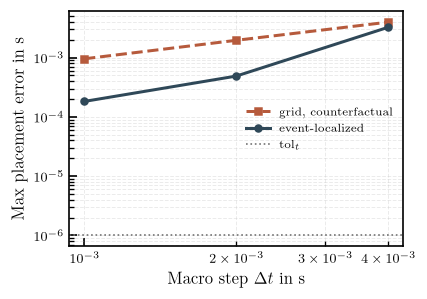

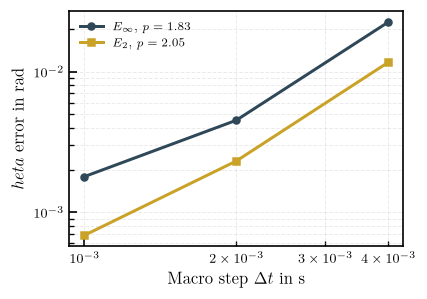

In [11]:
# Two separate results, so two numbered figures rather than two panels:
# evidence_plan.md section 3 registers F1 (placement) and F2 (convergence)
# independently, and the SMPT requirements ask for a split where panels do not
# form one argument.
suffix = "_smoke" if SMOKE else ""

steps = np.array(sorted(runs), dtype=float)
localized = np.array(
    [np.nan if per_switch[dt][0] is None else per_switch[dt][0].max() for dt in steps]
)
grid = np.array([per_switch[dt][1].max() for dt in steps])
# Recorded rather than plotted: the indicator residual at the located instant is
# bisection quality against the trajectory the algorithm actually saw, which is
# a different quantity from the placement error against the refined reference.
# F1 plots the placement error; this goes into the payload beside it.
residuals = np.array([
    np.max(np.abs(runs[dt].boundary_residuals_deg))
    if runs[dt].boundary_residuals_deg.size else np.nan
    for dt in steps
])

# F1 - placement error against macro step, with the grid counterfactual.
fig, ax = plt.subplots(figsize=(0.62 * FULL_WIDTH, 0.44 * FULL_WIDTH))
ax.loglog(steps, grid, "s--", color="#B65A3C", label="grid, counterfactual")
ax.loglog(steps, np.maximum(localized, 1e-16), "o-", color="#2F4858",
          label="event-localized")
ax.axhline(EVENT_TOL_TIME, color="0.45", linestyle=":", linewidth=1.0,
           label=r"$\mathrm{tol}_t$")
ax.set_xlabel(r"Macro step $\Delta t$ in s")
ax.set_ylabel(r"Max placement error in s")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / f"F1_placement{suffix}.pdf", bbox_inches="tight")
plt.show()

# F2 - trajectory convergence with the fitted observed order.
fig, ax = plt.subplots(figsize=(0.62 * FULL_WIDTH, 0.44 * FULL_WIDTH))
ax.loglog(df_error["macro_dt_s"], df_error["e_inf"], "o-", color="#2F4858",
          label=rf"$E_\infty$,  $p={order_inf:.2f}$")
ax.loglog(df_error["macro_dt_s"], df_error["e_2"], "s-", color="#C9A227",
          label=rf"$E_2$,  $p={order_2:.2f}$")
ax.set_xlabel(r"Macro step $\Delta t$ in s")
ax.set_ylabel(r"$	heta$ error in rad")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / f"F2_convergence{suffix}.pdf", bbox_inches="tight")
plt.show()


## Emit the numbers

F1 and F2 of the evidence register. A smoke run lands in `*.smoke.json` and can
never overwrite a campaign result.

In [12]:
# Destination resolution lives in record.py so every notebook agrees on it.
results_root, _results_source = paper_results_dir(_repo)
print(f"results destination: {_results_source}")

f1_path = record(
    "F1",
    {
        "macro_steps_s": steps,
        "max_placement_error_localized_s": localized,
        "max_placement_error_grid_counterfactual_s": grid,
        "max_abs_indicator_residual_deg": residuals,
        "reference_switch_times_s": reference.switch_times,
        "reference_switch_labels": reference.switch_labels,
        "bisection_tol_time_s": EVENT_TOL_TIME,
        "per_step": {
            f"{dt:.6e}": {
                "n_switches": int(len(runs[dt].switch_times)),
                "switch_times_s": runs[dt].switch_times,
                "placement_error_s": (
                    None if per_switch[dt][0] is None else per_switch[dt][0]
                ),
                "grid_counterfactual_s": per_switch[dt][1],
                "boundary_times_s": runs[dt].boundary_times,
                "indicator_residual_deg": runs[dt].boundary_residuals_deg,
                "wall_s": runs[dt].wall_s,
            }
            for dt in steps
        },
    },
    notebook="05_placement",
    smoke=SMOKE,
    directory=results_root,
    extra_provenance=RUN_ENV,
)

f2_path = record(
    "F2",
    {
        "macro_steps_s": df_error["macro_dt_s"].to_numpy(),
        "e_inf_rad": df_error["e_inf"].to_numpy(),
        "e_2_rad": df_error["e_2"].to_numpy(),
        "observed_order_e_inf": order_inf,
        "observed_order_e_2": order_2,
        "r_squared_e_inf": r2_inf,
        "r_squared_e_2": r2_2,
        "reference_macro_dt_s": DT_REF,
        "fem_internal_dt_s": FEM_INTERNAL_DT,
    },
    notebook="05_placement",
    smoke=SMOKE,
    directory=results_root,
    extra_provenance=RUN_ENV,
)

def _shown(path):
    """Shortest non-absolute rendering, so no machine layout is recorded."""
    for base in (_repo.parent, results_root.parent, results_root):
        try:
            return path.relative_to(base)
        except ValueError:
            continue
    return path.name


print(_shown(f1_path))
print(_shown(f2_path))

results destination: sibling SysSimX-Framework-Paper checkout
SysSimX-Framework-Paper\results\F1.smoke.json
SysSimX-Framework-Paper\results\F2.smoke.json


## Reading the result

State three things when this reaches the paper, and no more than three.

1. **Localization against placement.** Report the indicator residual and the
   placement error separately. The residual says whether bisection did its job;
   the placement error says where the switch actually landed in time. If the
   placement error scales with the macro step while the residual stays at
   tolerance, the limit is the coupled trajectory and not the localization, and
   the paper has to say so in those words.
2. **Order.** The fitted slope with its coefficient of determination and the
   range of steps it was fitted over. A single number without the range is not a
   convergence result.
3. **What the grid column is.** A counterfactual computed from the located
   crossing, not a measured run, because `mode_selector` was removed in
   `c306370`. It bounds placement only; it says nothing about the trajectory a
   grid-placed switch would have produced. If the localized error exceeds it at
   coarse steps, that is a real finding, not a defect to tune away.

Limitations that belong beside the numbers: one pendulum, one controller, one
boundary pair, contact-free, and a reference that is a refinement of the same
scheme rather than an independent solution.